## obtendo graficos e metricas uteis dos modelos treinados

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

In [2]:
print("Diretório atual:")
print(Path.cwd())

Diretório atual:
c:\Users\cooki\Documents\GitHub\FOCA\Source\AI\src\notebooks


In [3]:
cwd = Path.cwd()

if (cwd / "src" / "models").exists():
    models_dir = cwd / "src" / "models"

elif (cwd.parent / "models").exists():
    # Caso o notebook esteja executando a partir de src/notebooks
    models_dir = cwd.parent / "models"

else:
    raise FileNotFoundError("Não foi possível localizar a pasta src/models.")

print("Pasta dos modelos:")
print(models_dir)

Pasta dos modelos:
c:\Users\cooki\Documents\GitHub\FOCA\Source\AI\src\models


In [4]:
modelos = [p for p in models_dir.iterdir() if p.is_dir()]

for i, modelo in enumerate(modelos):
    print(i, modelo.name)

0 yolov8_nano_foca_v3_800_50e


In [6]:
model_dir = modelos[0]

print("Modelo selecionado:")
print(model_dir)

Modelo selecionado:
c:\Users\cooki\Documents\GitHub\FOCA\Source\AI\src\models\yolov8_nano_foca_v3_800_50e


In [7]:
for arquivo in sorted(model_dir.iterdir()):
    print(arquivo.name)

args.yaml
BoxF1_curve.png
BoxP_curve.png
BoxPR_curve.png
BoxR_curve.png
confusion_matrix.png
confusion_matrix_normalized.png
labels.jpg
results.csv
results.png
train_batch0.jpg
train_batch1.jpg
train_batch2.jpg
train_batch64400.jpg
train_batch64401.jpg
train_batch64402.jpg
val_batch0_labels.jpg
val_batch0_pred.jpg
val_batch1_labels.jpg
val_batch1_pred.jpg
val_batch2_labels.jpg
val_batch2_pred.jpg
weights


In [11]:
results_path = model_dir / "results.csv"

df = pd.read_csv(results_path, skipinitialspace=True)

df.head()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,lr/pg3,lr/pg4,lr/pg5,lr/pg6,lr/pg7
0,1,551.989,1.87280,1.59624,1.18092,0.74220,0.49999,0.55239,0.27297,1.64744,1.11567,1.09270,0.009994,0.003331,0.009994,0.003331,0.009994,0.003331,0.009994,0.003331
1,2,1024.770,1.70803,1.08563,1.07319,0.78593,0.51206,0.57234,0.28863,1.60417,0.94286,1.07765,0.019598,0.006533,0.019598,0.006533,0.019598,0.006533,0.019598,0.006533
2,3,1469.980,1.72913,1.06438,1.08827,0.76915,0.48883,0.54945,0.28300,1.62592,0.99043,1.09735,0.028806,0.009602,0.028806,0.009602,0.028806,0.009602,0.028806,0.009602
3,4,1906.800,1.72306,1.05230,1.08890,0.79186,0.51932,0.58768,0.30109,1.57944,0.90810,1.08439,0.028218,0.009406,0.028218,0.009406,0.028218,0.009406,0.028218,0.009406
4,5,2341.580,1.66492,0.98363,1.07941,0.81243,0.53643,0.60784,0.31502,1.54409,0.87445,1.07225,0.027624,0.009208,0.027624,0.009208,0.027624,0.009208,0.027624,0.009208


In [12]:
df.columns = df.columns.str.strip()

In [13]:
metricas = df[
    [
        "epoch",
        "metrics/precision(B)",
        "metrics/recall(B)",
        "metrics/mAP50(B)",
        "metrics/mAP50-95(B)"
    ]
]

metricas.head()

,epoch,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B)
0,1,0.74220,0.49999,0.55239,0.27297
1,2,0.78593,0.51206,0.57234,0.28863
2,3,0.76915,0.48883,0.54945,0.28300
3,4,0.79186,0.51932,0.58768,0.30109
4,5,0.81243,0.53643,0.60784,0.31502


In [14]:
print("Número de épocas:", len(df))

print("\nÚltima época:")
display(
    df[
        [
            "epoch",
            "metrics/precision(B)",
            "metrics/recall(B)",
            "metrics/mAP50(B)",
            "metrics/mAP50-95(B)"
        ]
    ].tail(1)
)

Número de épocas: 50

Última época:


,epoch,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B)
49,50,0.86363,0.63496,0.70885,0.38347


In [15]:
melhor_idx = df["metrics/mAP50-95(B)"].idxmax()

melhor_epoca = df.loc[
    melhor_idx,
    [
        "epoch",
        "metrics/precision(B)",
        "metrics/recall(B)",
        "metrics/mAP50(B)",
        "metrics/mAP50-95(B)"
    ]
]

melhor_epoca

epoch                   49.00000
metrics/precision(B)     0.86300
metrics/recall(B)        0.63485
metrics/mAP50(B)         0.70876
metrics/mAP50-95(B)      0.38387
Name: 48, dtype: float64

In [16]:
sns.set_theme(style="whitegrid")

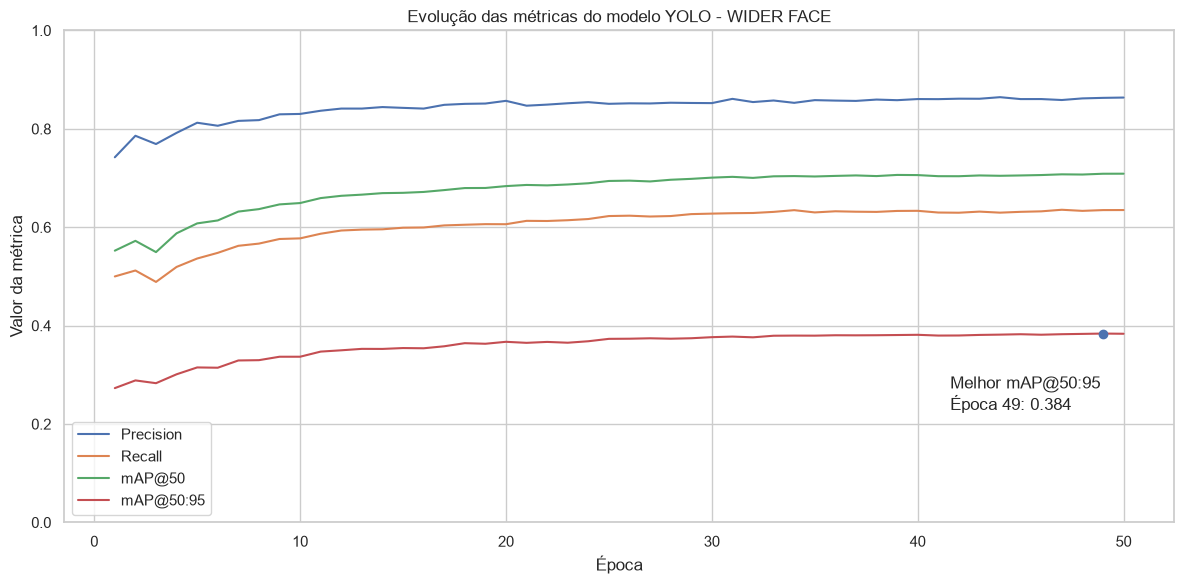

In [20]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df,
    x="epoch",
    y="metrics/precision(B)",
    label="Precision"
)

sns.lineplot(
    data=df,
    x="epoch",
    y="metrics/recall(B)",
    label="Recall"
)

sns.lineplot(
    data=df,
    x="epoch",
    y="metrics/mAP50(B)",
    label="mAP@50"
)

sns.lineplot(
    data=df,
    x="epoch",
    y="metrics/mAP50-95(B)",
    label="mAP@50:95"
)

melhor_idx = df["metrics/mAP50-95(B)"].idxmax()
melhor_epoca = df.loc[melhor_idx, "epoch"]
melhor_map = df.loc[melhor_idx, "metrics/mAP50-95(B)"]

plt.scatter(
    melhor_epoca,
    melhor_map,
    zorder=5
)

plt.annotate(
    f"Melhor mAP@50:95\nÉpoca {int(melhor_epoca)}: {melhor_map:.3f}",
    xy=(melhor_epoca, melhor_map),
    xytext=(-110, -55),
    textcoords="offset points",
    arrowprops={"arrowstyle": "->"}
)

plt.title("Evolução das métricas do modelo YOLO - WIDER FACE")
plt.xlabel("Época")
plt.ylabel("Valor da métrica")
plt.ylim(0, 1)

plt.legend()
plt.tight_layout()

plt.savefig(
    "metricas_treinamento.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

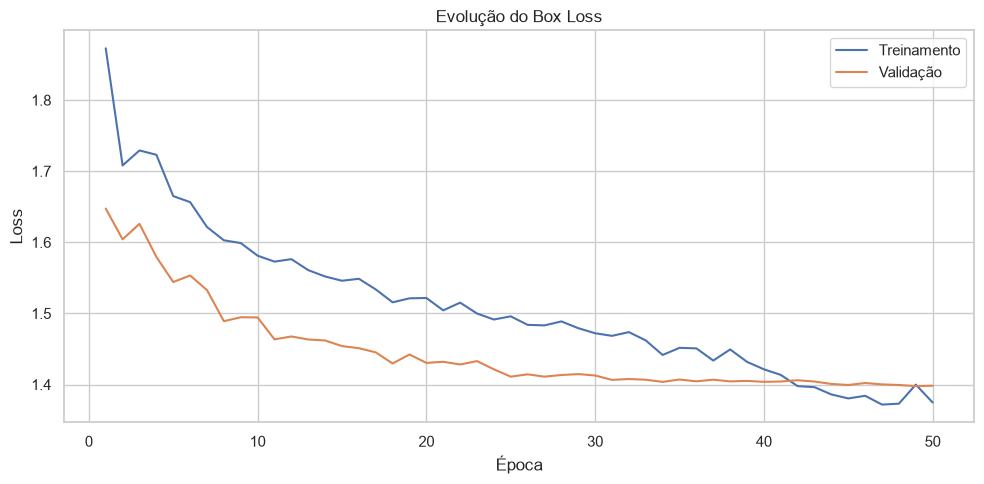

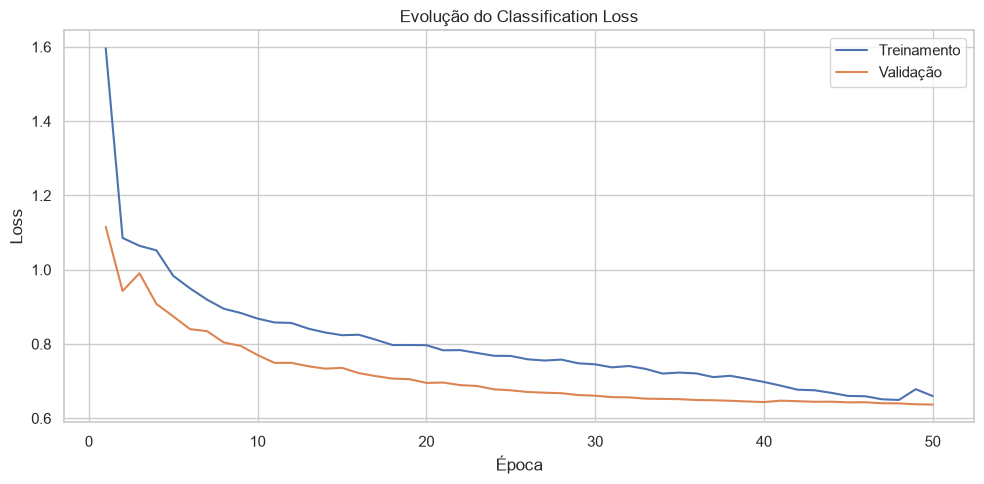

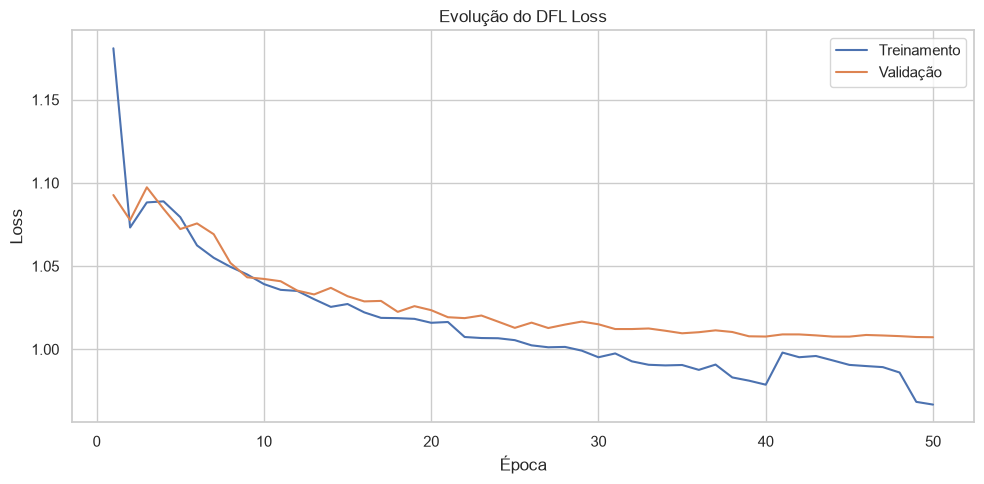

In [21]:
losses = {
    "Box Loss": ("train/box_loss", "val/box_loss"),
    "Classification Loss": ("train/cls_loss", "val/cls_loss"),
    "DFL Loss": ("train/dfl_loss", "val/dfl_loss")
}

for titulo, (train_col, val_col) in losses.items():
    plt.figure(figsize=(10, 5))

    sns.lineplot(
        data=df,
        x="epoch",
        y=train_col,
        label="Treinamento"
    )

    sns.lineplot(
        data=df,
        x="epoch",
        y=val_col,
        label="Validação"
    )

    plt.title(f"Evolução do {titulo}")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    
    plt.legend()
    plt.tight_layout()

    plt.show()

In [22]:
loss_summary = pd.DataFrame({
    "Loss": [
        "Box Loss",
        "Classification Loss",
        "DFL Loss"
    ],
    
    "Treino inicial": [
        df["train/box_loss"].iloc[0],
        df["train/cls_loss"].iloc[0],
        df["train/dfl_loss"].iloc[0]
    ],
    
    "Treino final": [
        df["train/box_loss"].iloc[-1],
        df["train/cls_loss"].iloc[-1],
        df["train/dfl_loss"].iloc[-1]
    ],
    
    "Validação inicial": [
        df["val/box_loss"].iloc[0],
        df["val/cls_loss"].iloc[0],
        df["val/dfl_loss"].iloc[0]
    ],
    
    "Validação final": [
        df["val/box_loss"].iloc[-1],
        df["val/cls_loss"].iloc[-1],
        df["val/dfl_loss"].iloc[-1]
    ]
})

loss_summary.round(4)

,Loss,Treino inicial,Treino final,Validação inicial,Validação final
0,Box Loss,1.8728,1.3747,1.6474,1.3983
1,Classification Loss,1.5962,0.6600,1.1157,0.6369
2,DFL Loss,1.1809,0.9667,1.0927,1.0072


### Análise das funções de perda

As curvas de perda apresentam redução progressiva ao longo das 50 épocas,
indicando convergência do processo de treinamento.

O Classification Loss apresentou a maior redução, passando de 1,5962 para
0,6600 no conjunto de treinamento e de 1,1157 para 0,6369 na validação.

O Box Loss também apresentou queda consistente, indicando melhora na
localização das caixas delimitadoras dos rostos.

No DFL Loss, observa-se estabilização da perda de validação nas últimas épocas,
enquanto a perda de treinamento continua apresentando uma pequena redução.
Esse comportamento indica diminuição dos ganhos de generalização no final do
treinamento, porém sem evidência clara de overfitting, uma vez que as perdas
de validação não apresentam crescimento significativo.

In [24]:
from matplotlib.ticker import PercentFormatter

metricas_cols = {
    "Precision": "metrics/precision(B)",
    "Recall": "metrics/recall(B)",
    "mAP@50": "metrics/mAP50(B)",
    "mAP@50:95": "metrics/mAP50-95(B)"
}

comparacao = pd.DataFrame({
    "Métrica": list(metricas_cols.keys()),
    "Época 1": [
        df[col].iloc[0]
        for col in metricas_cols.values()
    ],
    "Época 50": [
        df[col].iloc[-1]
        for col in metricas_cols.values()
    ]
})

comparacao

,Métrica,Época 1,Época 50
0,Precision,0.74220,0.86363
1,Recall,0.49999,0.63496
2,mAP@50,0.55239,0.70885
3,mAP@50:95,0.27297,0.38347


In [25]:
comparacao_long = comparacao.melt(
    id_vars="Métrica",
    var_name="Momento",
    value_name="Valor"
)

comparacao_long

,Métrica,Momento,Valor
0,Precision,Época 1,0.74220
1,Recall,Época 1,0.49999
2,mAP@50,Época 1,0.55239
3,mAP@50:95,Época 1,0.27297
4,Precision,Época 50,0.86363
5,Recall,Época 50,0.63496
6,mAP@50,Época 50,0.70885
7,mAP@50:95,Época 50,0.38347


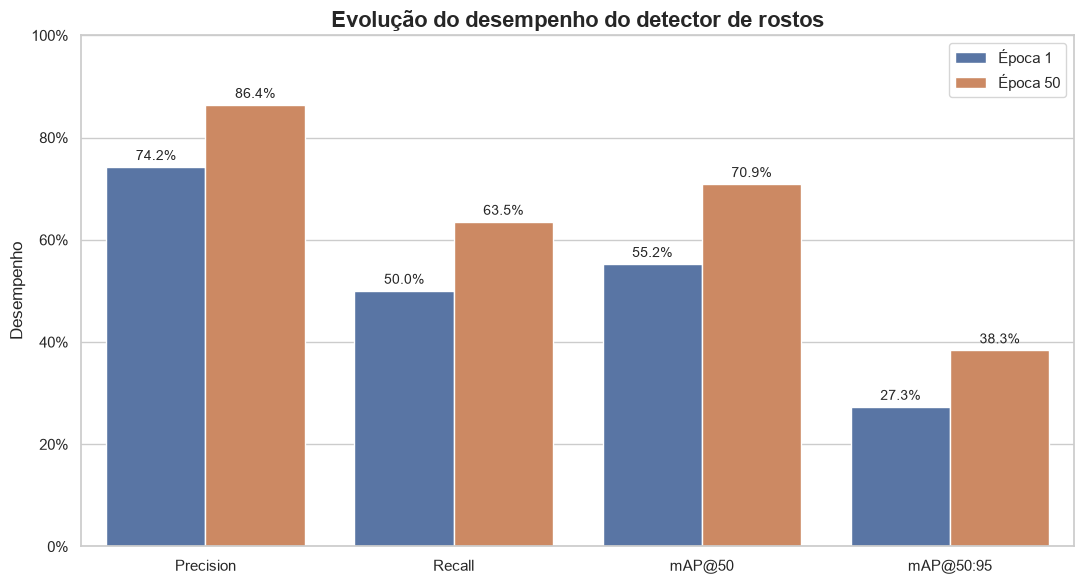

In [26]:
plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=comparacao_long,
    x="Métrica",
    y="Valor",
    hue="Momento"
)

ax.yaxis.set_major_formatter(PercentFormatter(1))

plt.title(
    "Evolução do desempenho do detector de rostos",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("")
plt.ylabel("Desempenho")

plt.ylim(0, 1)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt=lambda x: f"{x * 100:.1f}%",
        padding=3,
        fontsize=10
    )

plt.legend(title="")
plt.tight_layout()

plt.show()

## principais
mAP@50: 55,2% → 70,9%

Precision: 74,2% → 86,4%

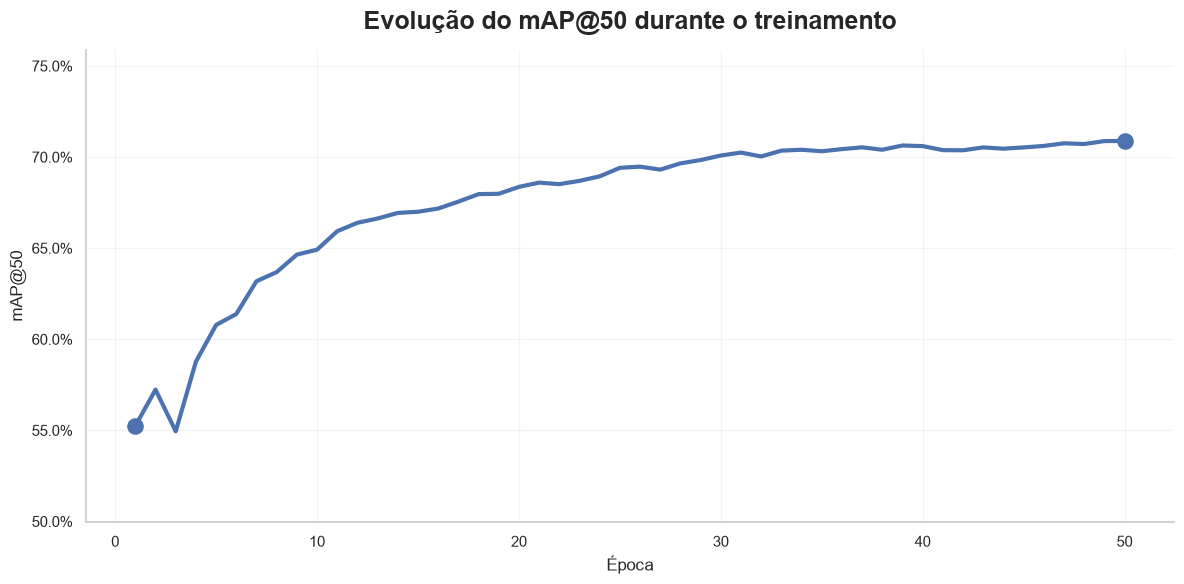

In [ ]:
from matplotlib.ticker import PercentFormatter

# Dados
epocas = df["epoch"]
map50 = df["metrics/mAP50(B)"]

map_inicial = map50.iloc[0]
map_final = map50.iloc[-1]

epoca_inicial = epocas.iloc[0]
epoca_final = epocas.iloc[-1]

ganho_pp = (map_final - map_inicial) * 100

# Gráfico
fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(
    x=epocas,
    y=map50,
    ax=ax,
    linewidth=3
)

# Pontos inicial e final
ax.scatter(
    [epoca_inicial, epoca_final],
    [map_inicial, map_final],
    s=120,
    zorder=5
)

# # Valor inicial
# ax.annotate(
#     f"{map_inicial:.1%}",
#     xy=(epoca_inicial, map_inicial),
#     xytext=(15, -25),
#     textcoords="offset points",
#     fontsize=12,
#     fontweight="bold"
# )

# # Valor final
# ax.annotate(
#     f"{map_final:.1%}",
#     xy=(epoca_final, map_final),
#     xytext=(-45, 15),
#     textcoords="offset points",
#     fontsize=12,
#     fontweight="bold"
# )

# Configuração
ax.set_title(
    "Evolução do mAP@50 durante o treinamento",
    fontsize=18,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Época", fontsize=12)
ax.set_ylabel("mAP@50", fontsize=12)

ax.yaxis.set_major_formatter(PercentFormatter(1))

ax.grid(alpha=0.2)

sns.despine()

plt.tight_layout()

plt.savefig(
    "evolucao_map50.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

grafico tuff

PRECISION
86,4%
Precisão das detecções

RECALL
63,5%
Rostos detectados

mAP@50
70,9%
Desempenho geral

mAP@50:95
38,3%
Avaliação rigorosa

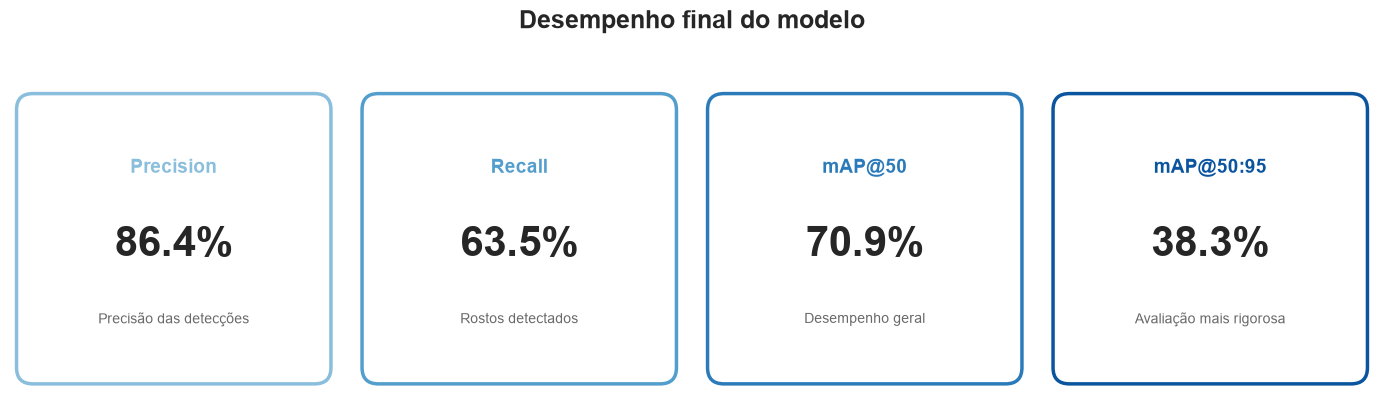

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import FancyBboxPatch

# Valores da última época
metricas_cards = {
    "Precision": df["metrics/precision(B)"].iloc[-1],
    "Recall": df["metrics/recall(B)"].iloc[-1],
    "mAP@50": df["metrics/mAP50(B)"].iloc[-1],
    "mAP@50:95": df["metrics/mAP50-95(B)"].iloc[-1]
}

descricoes = {
    "Precision": "Precisão das detecções",
    "Recall": "Rostos detectados",
    "mAP@50": "Desempenho geral",
    "mAP@50:95": "Avaliação mais rigorosa"
}

sns.set_theme(style="white")

cores = sns.color_palette("Blues", 6)[2:]

fig, axes = plt.subplots(
    1,
    4,
    figsize=(14, 4)
)

for ax, (nome, valor), cor in zip(
    axes,
    metricas_cards.items(),
    cores
):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    # Card
    card = FancyBboxPatch(
        (0.05, 0.08),
        0.9,
        0.84,
        boxstyle="round,pad=0.03,rounding_size=0.05",
        facecolor="white",
        edgecolor=cor,
        linewidth=2.5
    )

    ax.add_patch(card)

    # Nome da métrica
    ax.text(
        0.5,
        0.72,
        nome,
        ha="center",
        va="center",
        fontsize=14,
        fontweight="bold",
        color=cor
    )

    # Valor principal
    ax.text(
        0.5,
        0.48,
        f"{valor:.1%}",
        ha="center",
        va="center",
        fontsize=30,
        fontweight="bold"
    )

    # Descrição
    ax.text(
        0.5,
        0.25,
        descricoes[nome],
        ha="center",
        va="center",
        fontsize=10,
        color="dimgray"
    )

fig.suptitle(
    "Desempenho final do modelo",
    fontsize=18,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()

plt.savefig(
    "cards_metricas_finais.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()